# Action finance profiles, pilot — oef / br-city-finance-feasibility, release v1

Profiles the current adaptation action bank through the Financing component for the 50 pilot cities: action needs (cost band, preparation complexity) against the city profile (credit screen, finance-push), producing the funding-gap bucket and the route-eligibility annotation. Rules and tunables: `data/pilot/action-profile-method.md`. This is route-eligibility-only scoring on held data, per the methodology's build order; no fund-by-fund matching.

In [1]:
# Parameters
ACTIONS_CSV = "sample/currentbankadaptationactions.csv"
CITY_PROFILE_CSV = "data/br_city_finance_profile_pilot.csv"
OUT_CSV = "data/pilot/action_city_finance_profiles.csv"
OUT_NEEDS = "data/action_needs.csv"
PUSH_STRONG_BUCKETS = {"established", "extensive"}   # from data/rules/finance_push_buckets.csv
N_PILOTS, N_ACTIONS = 50, 53

import pandas as pd, json
print("expecting", N_ACTIONS, "actions x", N_PILOTS, "cities")

expecting 53 actions x 50 cities


## Load raw

In [2]:
# Load raw: adaptation action bank (CityCatalyst export)
actions = pd.read_csv(ACTIONS_CSV, dtype=str)
actions.shape

(53, 10)

In [3]:
# Load raw: pilot city finance profile (release v1 table)
cities = pd.read_csv(CITY_PROFILE_CSV, dtype=str)
cities.shape

(50, 40)

## Derive the action needs

Capital intensity is the bank's cost band as delivered. Preparation complexity is mapped from the action subcategory (regulation cheapest, plans and programmes middle, physical works highest); the mapping is a tunable documented in the method note.

In [4]:
# Derive: preparation complexity from subcategory (tunable mapping)
needs_rules = pd.read_csv("data/rules/action_needs_rules.csv", dtype=str)
PREP_MAP = needs_rules[needs_rules["rule"].eq("prep_complexity")].set_index("key")["value"].to_dict()
act = actions.rename(columns={"ActionID": "action_id", "ActionName": "action_name",
                              "CostInvestmentNeeded": "cost_band", "ActionSubcategory": "subcategory"})
act = act[["action_id", "action_name", "subcategory", "cost_band", "Hazards"]].copy()
act["prep_complexity"] = act["subcategory"].map(PREP_MAP)
assert act["prep_complexity"].notna().all(), act.loc[act.prep_complexity.isna(), "subcategory"].unique()
assert act["cost_band"].isin(["low", "medium", "high"]).all()
import os
os.makedirs("data", exist_ok=True)
act.rename(columns={"cost_band": "capital_intensity"}).assign(cost_band=act["cost_band"]).to_csv(OUT_NEEDS, index=False)
print("step-2 dataset:", OUT_NEEDS)
act.groupby(["cost_band", "prep_complexity"]).size().unstack(fill_value=0)

step-2 dataset: data/action_needs.csv


prep_complexity,high,low,medium
cost_band,,,
high,5,0,3
low,6,1,7
medium,17,2,12


## Derive the city axes

In [5]:
# Derive: the two city axes from the profile (credit gate, finance-push)
cit = cities[["locode", "name", "cod_mun", "uf", "capag", "credit_screen",
              "finance_push_score", "finance_push_bucket", "civil_defence_body_status", "pop_band"]].copy()
cit["fiscal_open"] = cit["credit_screen"].eq("credit_screen_pass")
cit["fiscal_unknown"] = cit["credit_screen"].eq("credit_screen_unknown")
cit["push_strong"] = cit["finance_push_bucket"].isin(PUSH_STRONG_BUCKETS)
cit[["fiscal_open", "push_strong"]].value_counts()

fiscal_open  push_strong
True         True           29
False        True           20
             False           1
Name: count, dtype: int64

## The gap ladder and route eligibility

One row per action-city pair. The funding gap follows the methodology's effort ladder; the routes annotation reads the held gates only (credit screen for A-credit/C, finance-push for B, civil-defence presence for E where the action addresses disaster hazards; A-grant is open by default; D is intermediated context; F is never scored).

In [6]:
# Derive: cross join and the funding-gap bucket
pairs = act.merge(cit, how="cross")

def funding_gap(r):
    money_ok = r["fiscal_open"]
    push_ok = r["push_strong"]
    if r["cost_band"] == "low":
        return "self_deliverable" if (push_ok or r["prep_complexity"] != "high") else "needs_technical_assistance"
    if money_ok and push_ok:
        return "own_budget_or_credit_feasible"
    if money_ok:
        return "own_budget_or_credit_feasible" if r["prep_complexity"] == "low" else "needs_technical_assistance"
    if push_ok:
        return "needs_external_cofinance"
    return "needs_cofinance_and_technical_assistance"

pairs["funding_gap"] = pairs.apply(funding_gap, axis=1)
pairs["funding_gap"].value_counts()

funding_gap
own_budget_or_credit_feasible               1131
needs_external_cofinance                     780
self_deliverable                             694
needs_cofinance_and_technical_assistance      39
needs_technical_assistance                     6
Name: count, dtype: int64

In [7]:
# Derive: route-eligibility annotation from held gates
DISASTER_HAZARDS = {"floods", "landslides", "storms", "droughts", "sea-level-rise", "wildfires"}

def routes(r):
    open_routes = ["A-grant"]
    if r["fiscal_open"]:
        open_routes += ["A-credit", "C"]
    open_routes.append("B" if r["push_strong"] else "B(binding)")
    hazards = set(json.loads(r["Hazards"]))
    if hazards & DISASTER_HAZARDS and r["civil_defence_body_status"] == "yes":
        open_routes.append("E")
    return " ".join(open_routes)

pairs["routes_open"] = pairs.apply(routes, axis=1)

GAP_TEXT = {
    "self_deliverable": "low-cost action within the city's own reach",
    "own_budget_or_credit_feasible": "cost is coverable via own budget or the open credit routes",
    "needs_technical_assistance": "money reachable but formulation capacity binds; technical assistance closes the gap",
    "needs_external_cofinance": "cost outruns fiscal capacity; the city can formulate toward grant and transfer routes",
    "needs_cofinance_and_technical_assistance": "both money and formulation capacity bind; grant routes plus technical assistance",
}
pairs["annotation"] = pairs.apply(lambda r: GAP_TEXT[r["funding_gap"]] + " [routes: " + r["routes_open"] + "]"
                                  + ("; credit screen unknown this snapshot" if r["fiscal_unknown"] else ""), axis=1)
pairs[["action_id", "name", "funding_gap", "routes_open"]].head(4)

,action_id,name,funding_gap,routes_open
0,c40_0046,Caxias do Sul,own_budget_or_credit_feasible,A-grant A-credit C B E
1,c40_0046,Maranguape,needs_external_cofinance,A-grant B E
2,c40_0046,Corumbá,own_budget_or_credit_feasible,A-grant A-credit C B E
3,c40_0046,Altamira,needs_external_cofinance,A-grant B E


## Validate

In [8]:
# Validate: shape, exhaustiveness, and rule sanity
assert len(pairs) == N_ACTIONS * N_PILOTS, len(pairs)
assert pairs["funding_gap"].notna().all() and pairs["routes_open"].notna().all()
# Low-cost actions never demand external co-finance on this ladder
assert not pairs.loc[pairs["cost_band"].eq("low"), "funding_gap"].str.contains("cofinance").any()
# A fiscally-open, push-strong city never lands below the feasible buckets
ok = pairs.loc[pairs["fiscal_open"] & pairs["push_strong"], "funding_gap"]
assert ok.isin(["self_deliverable", "own_budget_or_credit_feasible"]).all()
# Route C never opens where the credit screen failed
assert not pairs.loc[~pairs["fiscal_open"], "routes_open"].str.contains("C").any()
print("all validations passed")

all validations passed


## Export

In [9]:
import os
os.makedirs("data/pilot", exist_ok=True)
out_cols = ["action_id", "action_name", "subcategory", "cost_band", "prep_complexity",
            "locode", "name", "cod_mun", "uf", "capag", "credit_screen",
            "finance_push_score", "finance_push_bucket", "funding_gap", "routes_open", "annotation"]
pairs[out_cols].to_csv(OUT_CSV, index=False)
print(OUT_CSV, pairs[out_cols].shape)

data/pilot/action_city_finance_profiles.csv (2650, 16)


## Visualise and fit

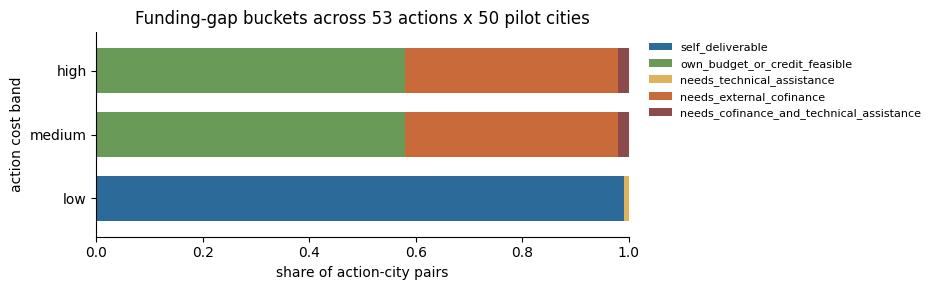

funding_gap,self_deliverable,own_budget_or_credit_feasible,needs_technical_assistance,needs_external_cofinance,needs_cofinance_and_technical_assistance
cost_band,,,,,
low,694,0,6,0,0
medium,0,899,0,620,31
high,0,232,0,160,8


In [10]:
# Chart: how the action bank lands across the pilot cities
import matplotlib.pyplot as plt
order = ["self_deliverable", "own_budget_or_credit_feasible", "needs_technical_assistance",
         "needs_external_cofinance", "needs_cofinance_and_technical_assistance"]
colors = {"self_deliverable": "#2b6a99", "own_budget_or_credit_feasible": "#6a9a58",
          "needs_technical_assistance": "#e0b25c", "needs_external_cofinance": "#c96a3b",
          "needs_cofinance_and_technical_assistance": "#8c4a4a"}
share = (pairs.groupby(["cost_band", "funding_gap"]).size().unstack(fill_value=0)
         .reindex(index=["low", "medium", "high"], columns=order, fill_value=0))
share_pct = share.div(share.sum(axis=1), axis=0)
ax = share_pct.plot.barh(stacked=True, figsize=(9.5, 3), color=[colors[c] for c in order], width=0.7)
ax.set_xlabel("share of action-city pairs")
ax.set_ylabel("action cost band")
ax.set_title("Funding-gap buckets across 53 actions x 50 pilot cities")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
share

In [11]:
# Fit: the methodology's worked example, reproduced with real pilots
# High-cost infrastructure (coastal protection, c40_0046) in a credit-closed, push-modest city vs a credit-open, push-strong city.
example = pairs[pairs["action_id"].eq("c40_0046")].copy()
cols = ["name", "capag", "credit_screen", "finance_push_score", "finance_push_bucket", "funding_gap", "routes_open"]
example.sort_values(["funding_gap", "name"])[cols].groupby("funding_gap").head(3)

,name,capag,credit_screen,finance_push_score,finance_push_bucket,funding_gap,routes_open
28,Ilhéus,C,credit_screen_fail_information_quality,6,developing,needs_cofinance_and_technical_assistance,A-grant B(binding) E
48,Abaetetuba,C,credit_screen_fail_fiscal,8,established,needs_external_cofinance,A-grant B E
3,Altamira,C,credit_screen_fail_fiscal,8,established,needs_external_cofinance,A-grant B E
10,Barcarena,n.d.,credit_screen_unknown,10,extensive,needs_external_cofinance,A-grant B E
37,Aracruz,A+,credit_screen_pass,11,extensive,own_budget_or_credit_feasible,A-grant A-credit C B E
5,Arapiraca,A+,credit_screen_pass,7,established,own_budget_or_credit_feasible,A-grant A-credit C B E
11,Boa Vista,A,credit_screen_pass,10,extensive,own_budget_or_credit_feasible,A-grant A-credit C B E


In [12]:
# Fit: which actions differentiate cities most (variance of bucket across pilots)
GAP_RANK = {g: i for i, g in enumerate(order)}
pairs["gap_rank"] = pairs["funding_gap"].map(GAP_RANK)
spread = pairs.groupby(["action_id", "action_name", "cost_band"])["gap_rank"].nunique().sort_values(ascending=False)
spread.head(10).to_frame("distinct_buckets_across_pilots")

,,,distinct_buckets_across_pilots
action_id,action_name,cost_band,
c40_0046,Strengthen coastal protection infrastructure,high,3
c40_0048,Upgrade urban drainage systems,medium,3
icare_0154,Clean and unclog drainage channels and install eco-barriers,medium,3
icare_0145,Strengthen the healthcare system to respond effectively to extreme events,high,3
icare_0144,Establish a financial support program for extreme weather events,medium,3
icare_0169,Establish a Plan for Preparation and Emergency Response Measures in the event of extreme weather events,high,3
icare_0170,Build safe housing and implement urban rehabilitation projects for populations living in high-risk areas,high,3
icare_0171,"Improve the hydrometeorological forecasting, monitoring, and alert system for climate risks",medium,3
icare_0162,Strengthen programs for control and conservation of protected areas,medium,3


## Findings

The bank profiles cleanly: every action carries a cost band and a mappable subcategory, so all 2,650 action-city pairs land in a bucket with a route annotation. Low-cost actions (plans, regulations, smaller programmes) are self-deliverable nearly everywhere, which matches the methodology's expectation that cheap actions look alike across cities; medium and high-cost actions are where the pilots diverge, driven jointly by the credit gate and finance-push. The worked example reproduces the pre-read's pattern with real cities: the same high-cost coastal action is credit-feasible in a CAPAG-A pilot and lands at co-finance-plus-assistance in a credit-closed, push-modest one, with the grant arm of Route A and (where civil defence exists) Route E still open. The main absence is unchanged: without the sector and adaptation-eligibility tags and the fund inventory, the annotation names route families, not funds.